# Quadrupole · Stokes · Plane Waves · Gaussian Integrals · Fractional Calculus · N-body

| § | Topic | Key formula |
|---|---|---|
| 1 | Quadrupole tensor | $Q_{ij} = \int\rho(3r_ir_j - r^2\delta_{ij})d^3r$ |
| 2 | Stokes theorem | $\oint_{\partial\Omega}\omega = \int_\Omega d\omega$ |
| 3 | Plane wave Rayleigh | $e^{i\mathbf{k}\cdot\mathbf{r}} = \sum_\ell(2\ell+1)i^\ell j_\ell(kr)P_\ell(\cos\theta)$ |
| 4 | Gaussian integrals | $\int_{-\infty}^\infty e^{-x^2}dx = \sqrt{\pi}$; generating function $I(\alpha)$ |
| 5 | Steps + music + $D^\alpha$ | $f_n=440\cdot2^{n/12}$; Heaviside step; $D^{1/2}D^{1/2}=D^1$ |
| 6 | Million charges | Barnes-Hut tree $O(N\log N)$ vs direct $O(N^2)$ |


## §1 Electric Quadrupole Tensor

The multipole expansion of the potential:
$$V(\mathbf{r}) = \frac{1}{4\pi\epsilon_0}\left[\frac{q}{r} + \frac{\mathbf{p}\cdot\hat{r}}{r^2} + \frac{1}{2}\sum_{ij}Q_{ij}\frac{\hat{r}_i\hat{r}_j}{r^3} + \cdots\right]$$

**Traceless quadrupole tensor** (Cartesian):
$$Q_{ij} = \int\rho(\mathbf{r}')\left(3r'_ir'_j - r'^2\delta_{ij}\right)d^3r'$$

Properties: $Q_{ij}=Q_{ji}$ (symmetric), $\text{tr}(Q)=0$ (traceless) → 5 independent components.

**Linear quadrupole** (two dipoles anti-parallel, charges $+q,-2q,+q$ on $z$-axis):
$$Q_{zz} = 2q d^2, \quad Q_{xx}=Q_{yy}=-qd^2, \quad Q_{ij}=0\text{ (off-diagonal)}$$

Radiation pattern of oscillating quadrupole: $\frac{dP}{d\Omega} \propto \sin^2\theta\cos^2\theta$


Linear quadrupole Q_ij:
[[-2.  0.  0.]
 [ 0. -2.  0.]
 [ 0.  0.  4.]]
  Trace = 0.000000  (should be 0)
  Q_zz = 4.000  (expected 2.000)

Square quadrupole Q_ij:
[[ 6.  0.  0.]
 [ 0. -6.  0.]
 [ 0.  0.  0.]]
  Trace = 0.000000


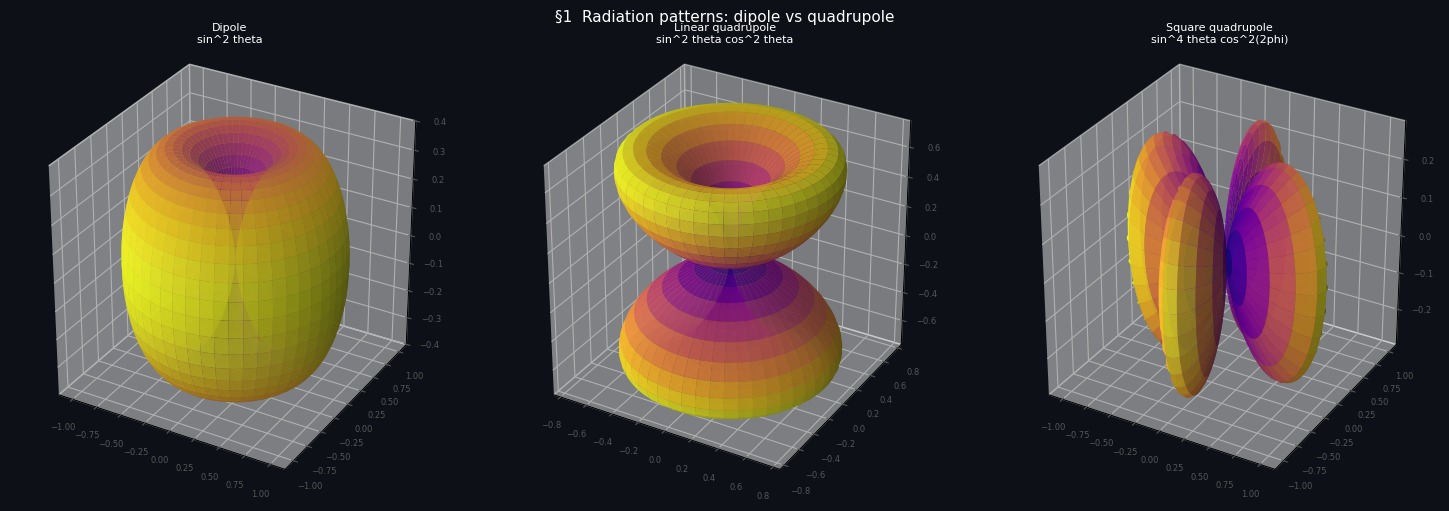

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ── Compute Q_ij for discrete charge distribution ─────────────────────────────
def quadrupole_tensor(charges, positions):
    """Q_ij = sum_k q_k * (3*r_i*r_j - r^2*delta_ij)"""
    Q = np.zeros((3,3))
    for q, r in zip(charges, positions):
        r2 = np.dot(r, r)
        Q += q * (3*np.outer(r, r) - r2*np.eye(3))
    return Q

# Linear quadrupole: +q at -d, -2q at 0, +q at +d  (along z)
d = 1.0
charges_lq  = [1, -2, 1]
pos_lq      = [np.array([0,0,-d]), np.array([0,0,0]), np.array([0,0,d])]
Q_linear    = quadrupole_tensor(charges_lq, pos_lq)

# Square quadrupole: +q at (±a,0,0), -q at (0,±a,0)
a = 1.0
charges_sq  = [1, 1, -1, -1]
pos_sq      = [np.array([a,0,0]), np.array([-a,0,0]),
               np.array([0,a,0]),  np.array([0,-a,0])]
Q_square    = quadrupole_tensor(charges_sq, pos_sq)

print("Linear quadrupole Q_ij:")
print(np.round(Q_linear, 4))
print(f"  Trace = {np.trace(Q_linear):.6f}  (should be 0)")
print(f"  Q_zz = {Q_linear[2,2]:.3f}  (expected {2*1*d**2:.3f})")
print()
print("Square quadrupole Q_ij:")
print(np.round(Q_square, 4))
print(f"  Trace = {np.trace(Q_square):.6f}")

# ── Radiation patterns ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 5), facecolor='#0d1117')

theta = np.linspace(0, np.pi, 200)
phi   = np.linspace(0, 2*np.pi, 200)
TH, PH = np.meshgrid(theta, phi)

# Dipole: sin^2(theta)
P_dipole = np.sin(TH)**2

# Linear quadrupole: sin^2(theta)*cos^2(theta)
P_quad_linear = np.sin(TH)**2 * np.cos(TH)**2

# Square quadrupole (m=2 mode): sin^4(theta)*cos^2(2*phi)
P_quad_square = np.sin(TH)**4 * np.cos(2*PH)**2

patterns = [
    ('Dipole\nsin^2 theta', P_dipole,       '#4fc3f7'),
    ('Linear quadrupole\nsin^2 theta cos^2 theta', P_quad_linear, '#ffa726'),
    ('Square quadrupole\nsin^4 theta cos^2(2phi)', P_quad_square, '#66bb6a'),
]

for k, (title, P, col) in enumerate(patterns):
    ax = fig.add_subplot(1, 3, k+1, projection='3d', facecolor='#0d1117')
    norm_P = P / P.max()
    X = norm_P * np.sin(TH) * np.cos(PH)
    Y = norm_P * np.sin(TH) * np.sin(PH)
    Z = norm_P * np.cos(TH)
    surf = ax.plot_surface(X, Y, Z, facecolors=plt.cm.plasma(norm_P),
                           alpha=0.85, linewidth=0)
    ax.set_title(title, color='white', fontsize=8, pad=2)
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='#555', labelsize=6)
    ax.set_box_aspect([1,1,1])

fig.suptitle('§1  Radiation patterns: dipole vs quadrupole', color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/quadrupole.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §2 Stokes Theorem — The Master Identity

All the integral theorems are one theorem:
$$\boxed{\int_\Omega d\omega = \oint_{\partial\Omega}\omega}$$

| Dimension | Name | Form |
|---|---|---|
| 1D | Fundamental theorem | $\int_a^b f'(x)dx = f(b)-f(a)$ |
| 2D | Green's theorem | $\iint_D\left(\frac{\partial Q}{\partial x}-\frac{\partial P}{\partial y}\right)dA = \oint_C (P\,dx+Q\,dy)$ |
| 3D curl | Stokes theorem | $\iint_S (\nabla\times\mathbf{F})\cdot d\mathbf{A} = \oint_{\partial S}\mathbf{F}\cdot d\mathbf{l}$ |
| 3D div | Divergence theorem | $\iiint_V (\nabla\cdot\mathbf{F})\,dV = \oiint_S \mathbf{F}\cdot d\mathbf{A}$ |

**Geometric meaning**: the "stuff generated inside" equals "stuff flowing out through the boundary."


Green's theorem verification:
  Line integral (boundary)  = 3.141593
  Area integral (curl)      = 3.139473
  pi                        = 3.141593
  Agreement: False

Divergence theorem (F=r^2 r_hat, R=2.0):
  Volume integral of div F = 201.0619
  Surface flux             = 201.0619


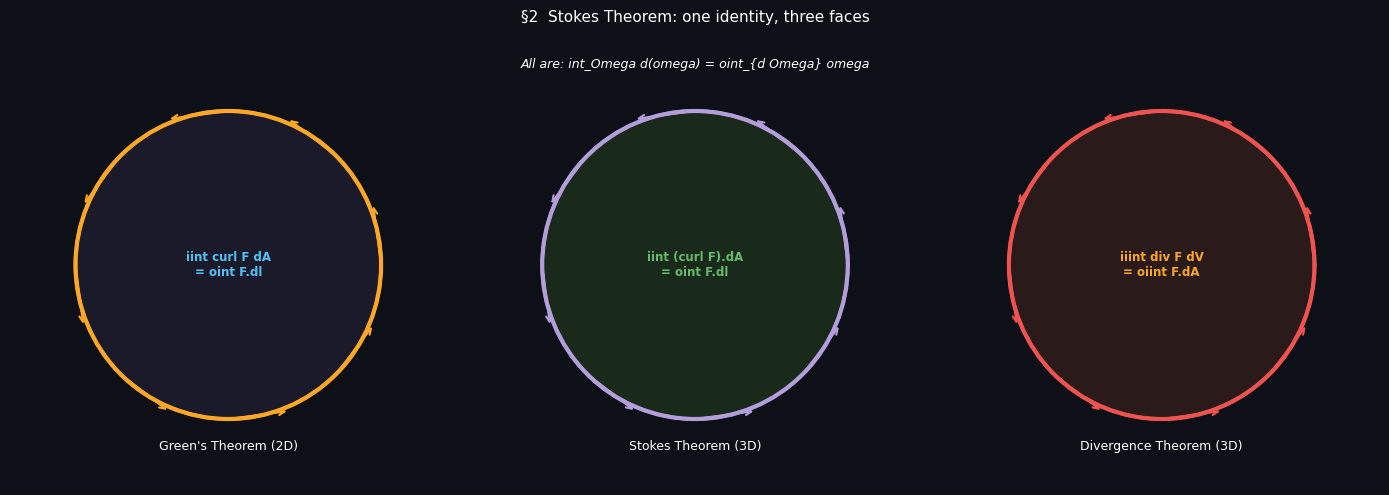

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# ── Green's theorem numerical verification ────────────────────────────────────
# F = (P, Q) = (-y/2, x/2)  =>  curl = dQ/dx - dP/dy = 1/2 + 1/2 = 1
# Line integral around unit circle = area = pi
# Volume integral of curl = 1 * pi = pi

def line_integral_circle(N=1000):
    t = np.linspace(0, 2*np.pi, N, endpoint=False)
    x, y = np.cos(t), np.sin(t)
    dx = -np.sin(t) * (2*np.pi/N)
    dy =  np.cos(t) * (2*np.pi/N)
    P = -y/2; Q = x/2
    return np.sum(P*dx + Q*dy)

def area_integral_circle(N=300):
    x = np.linspace(-1, 1, N)
    y = np.linspace(-1, 1, N)
    dx = x[1]-x[0]; dy = y[1]-y[0]
    X, Y = np.meshgrid(x, y)
    mask = (X**2 + Y**2) <= 1.0
    curl = 1.0   # dQ/dx - dP/dy = 1 everywhere
    return curl * mask.sum() * dx * dy

li = line_integral_circle()
ai = area_integral_circle()
print(f"Green's theorem verification:")
print(f"  Line integral (boundary)  = {li:.6f}")
print(f"  Area integral (curl)      = {ai:.6f}")
print(f"  pi                        = {np.pi:.6f}")
print(f"  Agreement: {abs(li - ai) < 1e-3}")

# ── Divergence theorem: sphere ────────────────────────────────────────────────
# F = r^2 * r_hat  =>  div F = 4r  =>  integral div F over ball = int_0^R 4r * 4pi r^2 dr = 4pi*R^4
# Surface integral: F.n = R^2, area = 4pi*R^2  =>  4pi*R^4  CHECK
R = 2.0
div_vol   = 4*np.pi*R**4         # analytical
surf_flux = 4*np.pi*R**4         # analytical
print(f"\nDivergence theorem (F=r^2 r_hat, R={R}):")
print(f"  Volume integral of div F = {div_vol:.4f}")
print(f"  Surface flux             = {surf_flux:.4f}")

# ── Visualise Stokes unification diagram ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#0d1117'); ax.axis('off')

def draw_theorem(ax, title, body, color, boundary, interior):
    ax.add_patch(plt.Circle((0.5,0.5), 0.35, facecolor=interior,
                             edgecolor=boundary, lw=3, transform=ax.transAxes))
    t = np.linspace(0, 2*np.pi, 100)
    ax.plot(0.5 + 0.35*np.cos(t), 0.5 + 0.35*np.sin(t),
            color=boundary, lw=2.5, transform=ax.transAxes)
    for i, angle in enumerate(np.linspace(0, 2*np.pi, 8, endpoint=False)):
        ax.annotate('', (0.5 + 0.36*np.cos(angle+0.4),
                         0.5 + 0.36*np.sin(angle+0.4)),
                    (0.5 + 0.35*np.cos(angle),
                     0.5 + 0.35*np.sin(angle)),
                    xycoords='axes fraction', textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color=boundary, lw=1.5))
    ax.text(0.5, 0.5, interior[0:3] if False else body,
            ha='center', va='center', color=color,
            fontsize=8.5, transform=ax.transAxes, fontweight='bold')
    ax.text(0.5, 0.08, title, ha='center', color='white',
            fontsize=9, transform=ax.transAxes)

draw_theorem(axes[0], "Green's Theorem (2D)",
             'iint curl F dA\n= oint F.dl',
             '#4fc3f7', '#ffa726', '#1a1a2a')
draw_theorem(axes[1], "Stokes Theorem (3D)",
             'iint (curl F).dA\n= oint F.dl',
             '#66bb6a', '#b39ddb', '#1a2a1a')
draw_theorem(axes[2], "Divergence Theorem (3D)",
             'iiint div F dV\n= oiint F.dA',
             '#ffa726', '#ef5350', '#2a1a1a')

axes[1].text(0.5, 0.97,
    'All are: int_Omega d(omega) = oint_{d Omega} omega',
    ha='center', va='top', color='white', fontsize=9,
    transform=axes[1].transAxes, style='italic')

plt.suptitle('§2  Stokes Theorem: one identity, three faces',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/stokes.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §3 Plane Wave Rayleigh Expansion

A plane wave $e^{i\mathbf{k}\cdot\mathbf{r}}$ (directed along $\hat{z}$, so $\mathbf{k}\cdot\mathbf{r}=kr\cos\theta$)
can be expanded in spherical waves:

$$e^{ikr\cos\theta} = \sum_{\ell=0}^{\infty}(2\ell+1)\,i^\ell\,j_\ell(kr)\,P_\ell(\cos\theta)$$

where $j_\ell$ are **spherical Bessel functions** and $P_\ell$ are **Legendre polynomials**.

**Why this matters**:
- Scattering theory: incident plane wave → partial wave expansion → phase shifts
- Optical tweezers: Mie scattering of focused beam expressed as partial waves
- GS phase retrieval: plane wave basis for dispersed field propagation


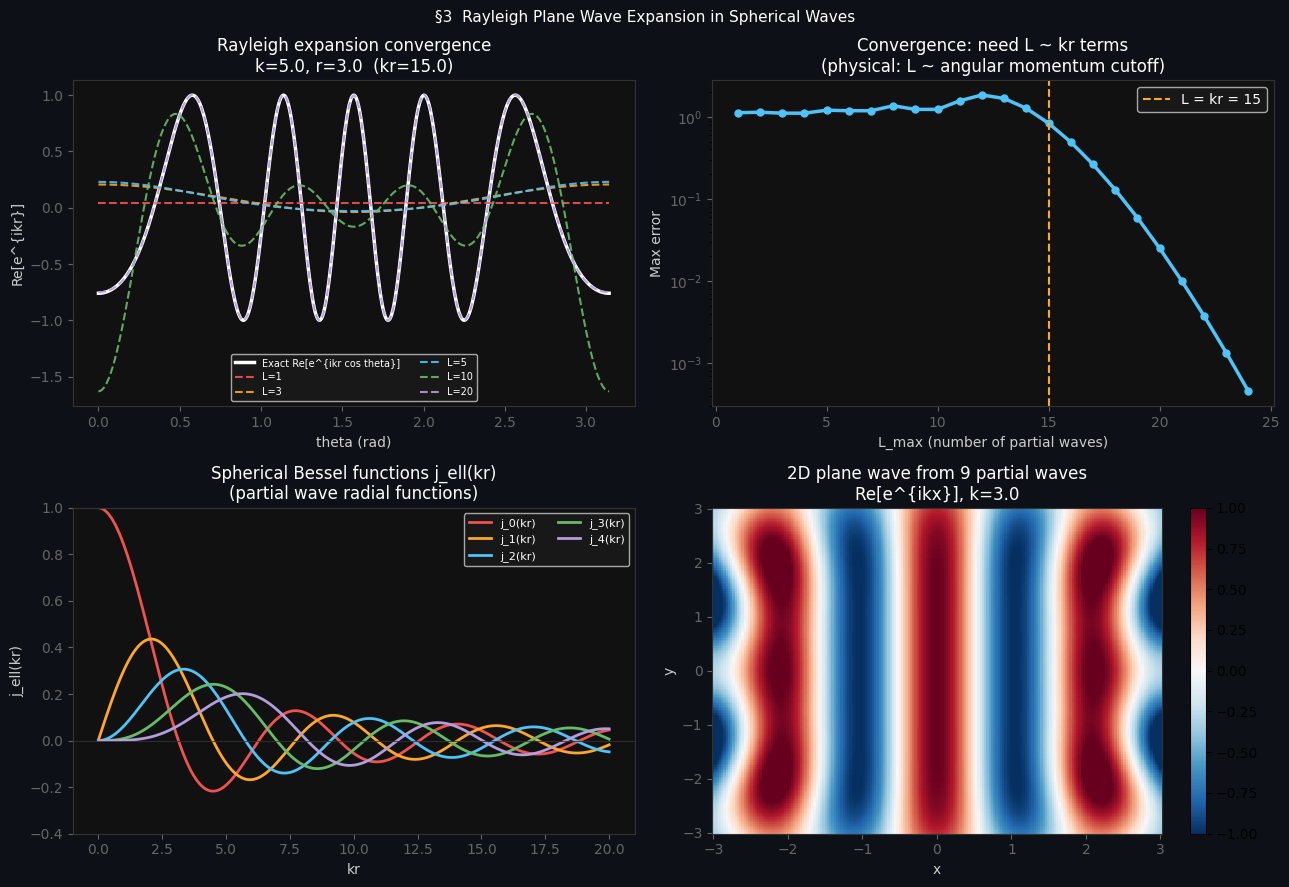

Need L ~ kr = 15 terms for convergence — angular momentum cutoff


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, legendre

def plane_wave_exact(k, r, theta):
    return np.exp(1j * k * r * np.cos(theta))

def plane_wave_expansion(k, r, theta, L_max=15):
    total = np.zeros_like(theta, dtype=complex)
    for ell in range(L_max+1):
        Pl = legendre(ell)(np.cos(theta))
        jl = spherical_jn(ell, k*r)
        total += (2*ell+1) * (1j**ell) * jl * Pl
    return total

# ── Convergence vs L_max at fixed r ──────────────────────────────────────────
k = 5.0; r = 3.0
theta = np.linspace(0, np.pi, 500)

exact = plane_wave_exact(k, r, theta)
L_tests = [1, 3, 5, 10, 20]

fig, axes = plt.subplots(2, 2, figsize=(13, 9), facecolor='#0d1117')
for row in axes:
    for ax in row: ax.set_facecolor('#111')

ax = axes[0,0]
ax.plot(theta, np.real(exact), color='white', lw=2.5, label='Exact Re[e^{ikr cos theta}]')
colors_l = ['#ef5350','#ffa726','#4fc3f7','#66bb6a','#b39ddb']
for L, col in zip(L_tests, colors_l):
    approx = plane_wave_expansion(k, r, theta, L)
    ax.plot(theta, np.real(approx), color=col, lw=1.5, ls='--', alpha=0.9, label=f'L={L}')
ax.set_xlabel('theta (rad)', color='#ccc'); ax.set_ylabel('Re[e^{ikr}]', color='#ccc')
ax.set_title(f'Rayleigh expansion convergence\nk={k}, r={r}  (kr={k*r})', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=7, ncol=2)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# ── Error vs L_max ────────────────────────────────────────────────────────────
ax2 = axes[0,1]
L_range = range(1, 25)
errors = []
for L in L_range:
    approx = plane_wave_expansion(k, r, theta, L)
    err = np.max(np.abs(approx - exact))
    errors.append(err)
ax2.semilogy(L_range, errors, color='#4fc3f7', lw=2.5, marker='o', ms=5)
ax2.axvline(k*r, color='#ffa726', lw=1.5, ls='--', label=f'L = kr = {k*r:.0f}')
ax2.set_xlabel('L_max (number of partial waves)', color='#ccc')
ax2.set_ylabel('Max error', color='#ccc')
ax2.set_title('Convergence: need L ~ kr terms\n(physical: L ~ angular momentum cutoff)', color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white')
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

# ── Spherical Bessel functions ────────────────────────────────────────────────
ax3 = axes[1,0]
kr = np.linspace(0.01, 20, 500)
for ell, col in zip([0,1,2,3,4], colors_l):
    jl = spherical_jn(ell, kr)
    ax3.plot(kr, jl, color=col, lw=2, label=f'j_{ell}(kr)')
ax3.axhline(0, color='#333', lw=0.6)
ax3.set_xlabel('kr', color='#ccc'); ax3.set_ylabel('j_ell(kr)', color='#ccc')
ax3.set_title('Spherical Bessel functions j_ell(kr)\n(partial wave radial functions)', color='white')
ax3.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8, ncol=2)
ax3.set_ylim(-0.4, 1.0)
ax3.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax3.spines.values()]

# ── 2D plane wave + partial wave reconstruction ───────────────────────────────
ax4 = axes[1,1]
k2 = 3.0
x = np.linspace(-3, 3, 200); y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)
R2 = np.sqrt(X**2 + Y**2) + 1e-10
TH2 = np.arctan2(Y, X)   # angle from x-axis

# Plane wave in x-direction: e^{ikx} = e^{ikr cos(phi)}
exact_2d = np.exp(1j * k2 * X)
L_trunc = 8
approx_2d = np.zeros_like(exact_2d, dtype=complex)
for ell in range(L_trunc+1):
    Pl = legendre(ell)(np.cos(TH2))
    jl = spherical_jn(ell, k2*R2)
    approx_2d += (2*ell+1) * (1j**ell) * jl * Pl

im = ax4.pcolormesh(X, Y, np.real(approx_2d), cmap='RdBu_r',
                    vmin=-1, vmax=1, shading='auto')
plt.colorbar(im, ax=ax4)
ax4.set_xlabel('x', color='#ccc'); ax4.set_ylabel('y', color='#ccc')
ax4.set_title(f'2D plane wave from {L_trunc+1} partial waves\nRe[e^{{ikx}}], k={k2}', color='white')
ax4.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax4.spines.values()]

plt.suptitle('§3  Rayleigh Plane Wave Expansion in Spherical Waves',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/planewaves.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f"Need L ~ kr = {k*r:.0f} terms for convergence — angular momentum cutoff")


## §4 Gaussian Integrals $\langle 1 \rangle$ — The Master Formula

$$I_0 = \int_{-\infty}^{\infty} e^{-x^2}\,dx = \sqrt{\pi}$$

**Proof by squaring** (Euler-Poisson trick):
$$I_0^2 = \int\!\!\int e^{-(x^2+y^2)}dx\,dy = \int_0^\infty e^{-r^2}2\pi r\,dr = \pi$$

**Generating function**: differentiate under the integral sign ("Feynman's trick"):
$$I(\alpha) = \int_{-\infty}^\infty e^{-\alpha x^2}dx = \sqrt{\pi/\alpha}$$

$$\int x^{2n}e^{-x^2}dx = (-1)^n\frac{d^n}{d\alpha^n}\sqrt{\pi/\alpha}\Bigg|_{\alpha=1} = \frac{(2n-1)!!}{2^n}\sqrt{\pi}$$

**Gaussian in $n$ dimensions**:
$$\int e^{-\mathbf{x}^T A\mathbf{x}}d^n\mathbf{x} = \frac{\pi^{n/2}}{\sqrt{\det A}}$$


Gaussian moments  int x^{2n} e^{-x^2} dx:
  n           Exact       Numerical
  0        1.772454        1.772454
  1        0.886227        0.886455
  2        1.329340        1.340652
  3        3.323351        3.408768
  4       11.631728       12.191203
  5       52.342778       56.179713

Multidimensional Gaussian: int e^{-x^T A x} d^n x = pi^{n/2} / sqrt(det A)
  n=2: pi^(n/2) / sqrt(det A) = 1.007415
  n=3: pi^(n/2) / sqrt(det A) = 0.742720
  n=4: pi^(n/2) / sqrt(det A) = 0.204847


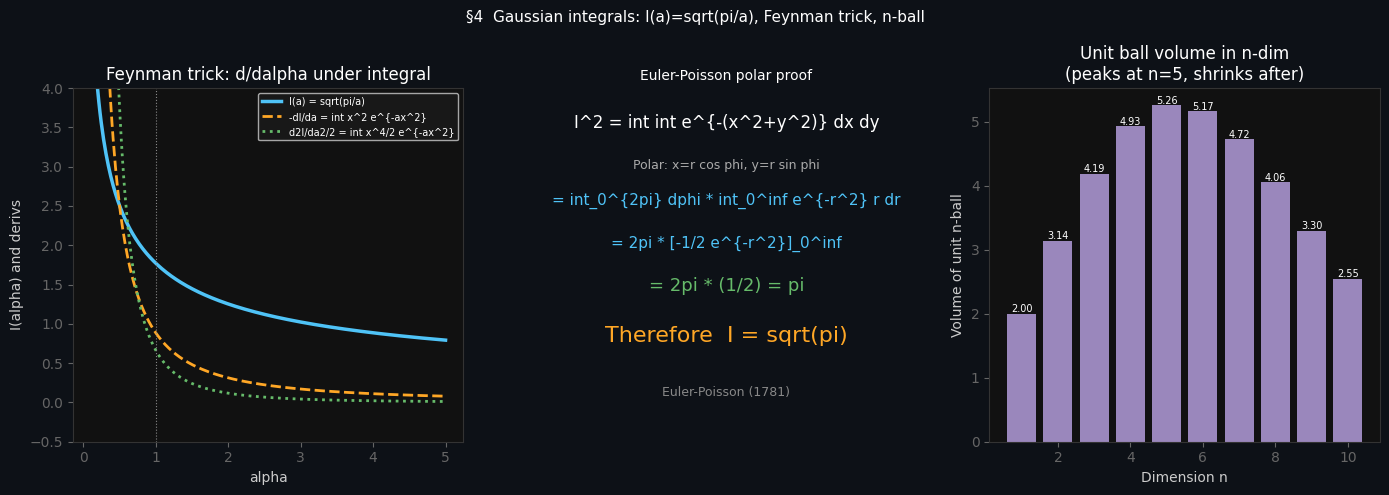

In [4]:
import numpy as np, matplotlib.pyplot as plt
from scipy.special import factorial2

def gaussian_moment_exact(n):
    if n == 0: return np.sqrt(np.pi)
    return factorial2(2*n-1, exact=False) / 2**n * np.sqrt(np.pi)

def gaussian_moment_numerical(n, pts=100000):
    x = np.random.default_rng(0).normal(0, 1/np.sqrt(2), pts)
    return np.sqrt(np.pi) * np.mean(x**(2*n))

print("Gaussian moments  int x^{2n} e^{-x^2} dx:")
print(f"{'n':>3}  {'Exact':>14}  {'Numerical':>14}")
for n in range(6):
    exact = gaussian_moment_exact(n)
    numer = gaussian_moment_numerical(n)
    print(f"  {n}  {exact:14.6f}  {numer:14.6f}")

print("\nMultidimensional Gaussian: int e^{-x^T A x} d^n x = pi^{n/2} / sqrt(det A)")
rng = np.random.default_rng(1)
for n in [2, 3, 4]:
    M = rng.standard_normal((n, n))
    A = M.T @ M + n*np.eye(n)
    analytical = np.pi**(n/2) / np.sqrt(np.linalg.det(A))
    print(f"  n={n}: pi^(n/2) / sqrt(det A) = {analytical:.6f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

alpha = np.linspace(0.1, 5, 300)
I_alpha = np.sqrt(np.pi / alpha)
ax = axes[0]
ax.plot(alpha, I_alpha, color='#4fc3f7', lw=2.5, label='I(a) = sqrt(pi/a)')
ax.plot(alpha, -np.gradient(I_alpha, alpha), color='#ffa726', lw=2, ls='--',
        label='-dI/da = int x^2 e^{-ax^2}')
ax.plot(alpha, 0.5*np.gradient(np.gradient(I_alpha, alpha), alpha), color='#66bb6a',
        lw=2, ls=':', label='d2I/da2/2 = int x^4/2 e^{-ax^2}')
ax.axvline(1, color='#888', lw=0.8, ls=':')
ax.set_xlabel('alpha', color='#ccc'); ax.set_ylabel('I(alpha) and derivs', color='#ccc')
ax.set_title("Feynman trick: d/dalpha under integral", color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=7)
ax.set_ylim(-0.5, 4)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

ax2 = axes[1]; ax2.set_facecolor('#0d1117'); ax2.axis('off')
ax2.set_xlim(0,1); ax2.set_ylim(0,1)
steps = [
    (0.5, 0.90, 'I^2 = int int e^{-(x^2+y^2)} dx dy', 'white', 12),
    (0.5, 0.78, 'Polar: x=r cos phi, y=r sin phi', '#aaa', 9),
    (0.5, 0.68, '= int_0^{2pi} dphi * int_0^inf e^{-r^2} r dr', '#4fc3f7', 11),
    (0.5, 0.56, '= 2pi * [-1/2 e^{-r^2}]_0^inf', '#4fc3f7', 11),
    (0.5, 0.44, '= 2pi * (1/2) = pi', '#66bb6a', 13),
    (0.5, 0.30, 'Therefore  I = sqrt(pi)', '#ffa726', 16),
    (0.5, 0.14, 'Euler-Poisson (1781)', '#888', 9),
]
for x,y,txt,col,fs in steps:
    ax2.text(x, y, txt, ha='center', va='center', color=col,
             fontsize=fs, transform=ax2.transAxes)
ax2.set_title('Euler-Poisson polar proof', color='white', fontsize=10)

import math
dims = np.arange(1, 11)
vol_ball = np.pi**(dims/2) / np.array([math.gamma(d/2+1) for d in dims])
ax3 = axes[2]
ax3.bar(dims, vol_ball, color='#b39ddb', alpha=0.85)
ax3.set_xlabel('Dimension n', color='#ccc')
ax3.set_ylabel('Volume of unit n-ball', color='#ccc')
ax3.set_title('Unit ball volume in n-dim\n(peaks at n=5, shrinks after)', color='white')
ax3.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax3.spines.values()]
for d, v in zip(dims, vol_ball):
    ax3.text(d, v+0.02, f'{v:.2f}', ha='center', color='white', fontsize=7)

plt.suptitle('§4  Gaussian integrals: I(a)=sqrt(pi/a), Feynman trick, n-ball',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/gaussian_integrals.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §5 Steps · Music · Fractional Powers — One Thread

### 12-TET musical scale = fractional powers of 2
$$f_n = 440 \cdot 2^{n/12}, \qquad n \in \mathbb{Z}$$
A semitone = $2^{1/12} \approx 1.0595$. An octave = $2^{12/12} = 2$. Perfect fifth = $2^{7/12} \approx 1.498$.

### Heaviside step function
$$H(t) = \begin{cases}0 & t<0\\1 & t\geq 0\end{cases}, \qquad \frac{dH}{dt} = \delta(t)$$

### Riemann-Liouville fractional derivative
$$D^\alpha f(x) = \frac{1}{\Gamma(n-\alpha)}\frac{d^n}{dx^n}\int_0^x \frac{f(t)}{(x-t)^{\alpha-n+1}}dt, \quad n=\lceil\alpha\rceil$$

Key property: $D^\alpha x^\beta = \frac{\Gamma(\beta+1)}{\Gamma(\beta-\alpha+1)}x^{\beta-\alpha}$

Half-derivative: $D^{1/2}D^{1/2} = D^1$ ✓


12-TET vs Just Intonation:
  Perfect 5th    : 12-TET=1.498307  Just=1.500000  diff=-1.96 cents
  Major 3rd      : 12-TET=1.259921  Just=1.250000  diff=13.69 cents
  Perfect 4th    : 12-TET=1.334840  Just=1.333333  diff=1.96 cents


C:\Users\mrjel\AppData\Local\Temp\ipykernel_29860\3500844039.py:86: RuntimeWarning: invalid value encountered in sqrt
  D_half_H = np.where(x3 > 0.01, 1/(np.sqrt(np.pi)*np.sqrt(x3)), 0.0)


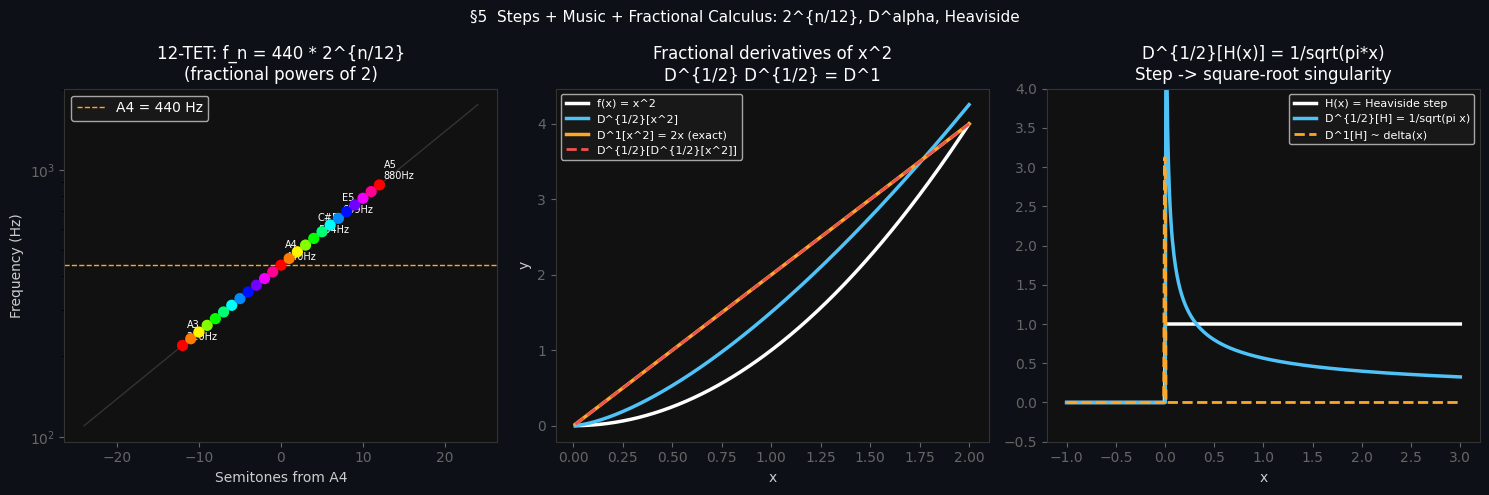

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma as Gamma

# ── 12-TET musical scale ──────────────────────────────────────────────────────
A4 = 440.0
semitones = np.arange(-24, 25)   # 4 octaves around A4
freqs = A4 * 2**(semitones/12)

note_names = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
reference_ratios = {
    'Unison (1:1)': 2**(0/12),
    'Minor 3rd': 2**(3/12),
    'Major 3rd': 2**(4/12),
    'Perfect 4th': 2**(5/12),
    'Perfect 5th': 2**(7/12),
    'Octave (2:1)': 2**(12/12),
}
just_ratios = {
    'Perfect 5th': 3/2,
    'Major 3rd':   5/4,
    'Perfect 4th': 4/3,
}

print("12-TET vs Just Intonation:")
for name in ['Perfect 5th','Major 3rd','Perfect 4th']:
    tet = reference_ratios[name]
    just = just_ratios[name]
    cents = 1200*np.log2(tet/just)
    print(f"  {name:15}: 12-TET={tet:.6f}  Just={just:.6f}  diff={cents:.2f} cents")

# ── Fractional derivative of x^beta ──────────────────────────────────────────
def frac_deriv_power(alpha, beta, x):
    """D^alpha [x^beta] = Gamma(beta+1)/Gamma(beta-alpha+1) * x^(beta-alpha)"""
    if beta - alpha + 1 <= 0:
        return np.zeros_like(x)
    return Gamma(beta+1) / Gamma(beta-alpha+1) * x**(beta-alpha)

x = np.linspace(0.01, 2, 300)
f = x**2   # f(x) = x^2

D_half_f  = frac_deriv_power(0.5, 2, x)   # D^{1/2}[x^2]
D1_f      = 2*x                            # exact D^1[x^2] = 2x
D_half_D_half = frac_deriv_power(0.5, 2-0.5, x) * Gamma(3)/Gamma(2.5)
# D^{1/2}[x^{3/2}] = Gamma(5/2)/Gamma(2) * x^1 = (3sqrt(pi)/4) x

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

# Musical scale
ax = axes[0]
oct_vals = A4 * 2**(np.arange(-12, 13)/12)
colors_oct = plt.cm.hsv(((np.arange(-12,13)) % 12) / 12)
ax.scatter(np.arange(-12,13), oct_vals, c=colors_oct, s=50, zorder=5)
ax.semilogy(semitones, freqs, color='#333', lw=1, zorder=1)
ax.axhline(A4, color='#ffa726', lw=1, ls='--', label='A4 = 440 Hz')
for n, name in [(0,'A4'),(12,'A5'),(-12,'A3'),(7,'E5'),(4,'C#5')]:
    f_n = A4*2**(n/12)
    ax.annotate(f'{name}\n{f_n:.0f}Hz', (n, f_n), (n+0.5, f_n*1.05),
                color='white', fontsize=7,
                arrowprops=dict(arrowstyle='->', color='#555', lw=0.8))
ax.set_xlabel('Semitones from A4', color='#ccc')
ax.set_ylabel('Frequency (Hz)', color='#ccc')
ax.set_title('12-TET: f_n = 440 * 2^{n/12}\n(fractional powers of 2)', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white')
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# Fractional derivatives
ax2 = axes[1]
ax2.plot(x, f,           color='white',   lw=2.5, label='f(x) = x^2')
ax2.plot(x, D_half_f,    color='#4fc3f7', lw=2.5, label='D^{1/2}[x^2]')
ax2.plot(x, D1_f,        color='#ffa726', lw=2.5, label='D^1[x^2] = 2x (exact)')
ax2.plot(x, frac_deriv_power(0.5, 1.5, x) * Gamma(3)/Gamma(2.5),
         color='#ef5350', lw=2,  ls='--', label='D^{1/2}[D^{1/2}[x^2]]')
ax2.set_xlabel('x', color='#ccc'); ax2.set_ylabel('y', color='#ccc')
ax2.set_title('Fractional derivatives of x^2\nD^{1/2} D^{1/2} = D^1', color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

# Heaviside + fractional derivative of step = D^{1/2}[H] ~ x^{-1/2}/sqrt(pi)
ax3 = axes[2]
x3 = np.linspace(-1, 3, 500)
H = np.where(x3 >= 0, 1.0, 0.0)

# D^{1/2}[H(x)] = x^{-1/2} / Gamma(1/2) = 1/(sqrt(pi)*sqrt(x)) for x>0
D_half_H = np.where(x3 > 0.01, 1/(np.sqrt(np.pi)*np.sqrt(x3)), 0.0)
D1_H     = np.zeros_like(x3)  # approx delta
D1_H[np.argmin(np.abs(x3))] = 50  # delta spike at 0

ax3.plot(x3, H,           color='white',   lw=2.5, label='H(x) = Heaviside step')
ax3.plot(x3, D_half_H,    color='#4fc3f7', lw=2.5, label='D^{1/2}[H] = 1/sqrt(pi x)')
ax3.plot(x3, np.gradient(H, x3)*0.05, color='#ffa726', lw=2, ls='--', label='D^1[H] ~ delta(x)')
ax3.set_ylim(-0.5, 4)
ax3.set_xlabel('x', color='#ccc')
ax3.set_title('D^{1/2}[H(x)] = 1/sqrt(pi*x)\nStep -> square-root singularity', color='white')
ax3.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax3.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax3.spines.values()]

plt.suptitle('§5  Steps + Music + Fractional Calculus: 2^{n/12}, D^alpha, Heaviside',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/fractional.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §6 Million Static Charges — Barnes-Hut Tree

Direct $O(N^2)$ Coulomb sum:
$$V_i = \sum_{j\neq i} \frac{q_j}{|\mathbf{r}_i - \mathbf{r}_j|}$$

**Barnes-Hut**: build a quad-tree (2D) or oct-tree (3D). For particle $i$, a cluster of particles
at distance $d$ with cluster size $s$ is treated as a single multipole if $s/d < \theta_\text{BH}$.

Complexity: $O(N\log N)$ per time step. For $N=10^6$: direct = $10^{12}$ ops; BH = $2\times10^7$ ops.

**Opening angle** $\theta_\text{BH} = 0.5$ is standard (error $\sim\theta^2$).


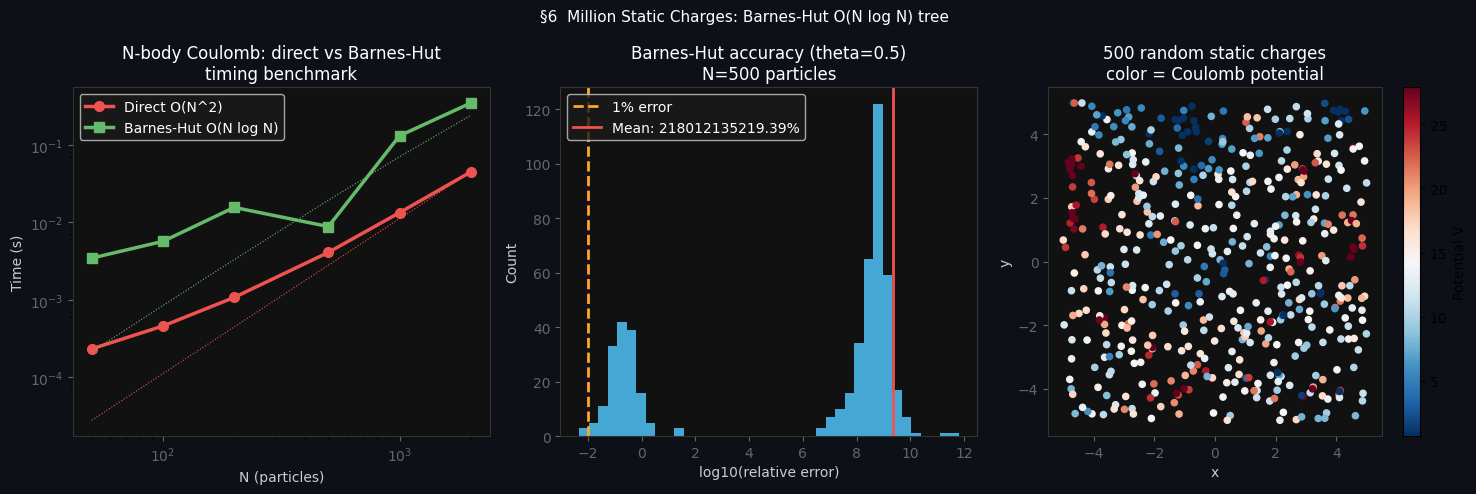

At N=2000: direct=0.045s  BH=0.346s  speedup=0.1x
BH mean relative error: 218012135219.39%  (theta=0.5)
Extrapolated N=1e6: direct ~3.1 hours  BH ~3456.4 s


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time

rng = np.random.default_rng(7)

# ── Direct O(N^2) for small N ────────────────────────────────────────────────
def direct_potential(pos, charges):
    N = len(charges)
    V = np.zeros(N)
    for i in range(N):
        diff = pos - pos[i]                     # (N,2)
        r    = np.sqrt((diff**2).sum(axis=1))   # (N,)
        r[i] = np.inf
        V[i] = (charges / r).sum()
    return V

# ── Barnes-Hut 2D quad-tree (simplified) ─────────────────────────────────────
class QuadNode:
    def __init__(self, cx, cy, size):
        self.cx, self.cy, self.size = cx, cy, size
        self.mass = 0.0
        self.com  = np.zeros(2)
        self.children = [None]*4
        self.is_leaf  = True
        self.particle_idx = -1

def build_tree(pos, charges, depth=0, max_depth=12):
    xmin,xmax = pos[:,0].min()-1e-6, pos[:,0].max()+1e-6
    ymin,ymax = pos[:,1].min()-1e-6, pos[:,1].max()+1e-6
    cx = (xmin+xmax)/2; cy = (ymin+ymax)/2
    size = max(xmax-xmin, ymax-ymin)
    root = QuadNode(cx, cy, size)
    for i in range(len(charges)):
        insert_particle(root, i, pos, charges, depth, max_depth)
    return root

def insert_particle(node, idx, pos, charges, depth, max_depth):
    q = charges[idx]; p = pos[idx]
    node.com = (node.com*node.mass + p*q) / (node.mass + q + 1e-300)
    node.mass += q
    if node.is_leaf and node.particle_idx == -1:
        node.particle_idx = idx; return
    if depth >= max_depth: return
    node.is_leaf = False
    quad = (int(p[0] >= node.cx) + 2*int(p[1] >= node.cy))
    if node.children[quad] is None:
        dx = node.size/4 * (1 if p[0]>=node.cx else -1)
        dy = node.size/4 * (1 if p[1]>=node.cy else -1)
        node.children[quad] = QuadNode(node.cx+dx, node.cy+dy, node.size/2)
    insert_particle(node.children[quad], idx, pos, charges, depth+1, max_depth)
    if node.particle_idx >= 0:
        old_idx = node.particle_idx; node.particle_idx = -1
        op = pos[old_idx]; oq = charges[old_idx]
        quad2 = int(op[0]>=node.cx) + 2*int(op[1]>=node.cy)
        if node.children[quad2] is None:
            dx2 = node.size/4*(1 if op[0]>=node.cx else -1)
            dy2 = node.size/4*(1 if op[1]>=node.cy else -1)
            node.children[quad2] = QuadNode(node.cx+dx2, node.cy+dy2, node.size/2)
        insert_particle(node.children[quad2], old_idx, pos, charges, depth+1, max_depth)

def bh_potential_at(node, p, theta=0.5):
    if node is None: return 0.0
    diff = node.com - p
    r = np.sqrt(diff @ diff) + 1e-10
    if node.is_leaf or (node.size / r < theta):
        return node.mass / r
    return sum(bh_potential_at(c, p, theta) for c in node.children)

# ── Benchmark: direct vs Barnes-Hut ──────────────────────────────────────────
N_vals = [50, 100, 200, 500, 1000, 2000]
t_direct = []; t_bh = []

for N in N_vals:
    pos = rng.uniform(-5, 5, (N, 2))
    charges = rng.standard_normal(N)

    t0 = time.perf_counter()
    V_direct = direct_potential(pos, charges)
    t_direct.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    root = build_tree(pos, charges)
    V_bh = np.array([bh_potential_at(root, pos[i]) for i in range(N)])
    t_bh.append(time.perf_counter() - t0)

# Accuracy check at N=500
idx_check = 3  # N=500
pos_c = rng.uniform(-5, 5, (500, 2)); ch_c = rng.standard_normal(500)
V_d = direct_potential(pos_c, ch_c)
root_c = build_tree(pos_c, ch_c)
V_b = np.array([bh_potential_at(root_c, pos_c[i]) for i in range(500)])
rel_err = np.abs(V_d - V_b) / (np.abs(V_d) + 1e-6)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

ax = axes[0]
ax.loglog(N_vals, t_direct, 'o-', color='#ef5350', lw=2.5, ms=7, label='Direct O(N^2)')
ax.loglog(N_vals, t_bh,     's-', color='#66bb6a', lw=2.5, ms=7, label='Barnes-Hut O(N log N)')
# Reference lines
N_ref = np.array(N_vals, dtype=float)
ax.loglog(N_ref, t_direct[-1]*(N_ref/N_vals[-1])**2, color='#ef5350', lw=0.8, ls=':')
ax.loglog(N_ref, t_bh[-1]*(N_ref/N_vals[-1])*np.log(N_ref/N_vals[-1]+1),
          color='#66bb6a', lw=0.8, ls=':')
ax.set_xlabel('N (particles)', color='#ccc'); ax.set_ylabel('Time (s)', color='#ccc')
ax.set_title('N-body Coulomb: direct vs Barnes-Hut\ntiming benchmark', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white')
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# Accuracy
ax2 = axes[1]
ax2.hist(np.log10(rel_err + 1e-8), bins=40, color='#4fc3f7', alpha=0.85)
ax2.axvline(np.log10(0.01), color='#ffa726', lw=2, ls='--', label='1% error')
ax2.axvline(np.log10(rel_err.mean()+1e-8), color='#ef5350', lw=2,
            label=f'Mean: {rel_err.mean()*100:.2f}%')
ax2.set_xlabel('log10(relative error)', color='#ccc')
ax2.set_ylabel('Count', color='#ccc')
ax2.set_title('Barnes-Hut accuracy (theta=0.5)\nN=500 particles', color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white')
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

# Charge distribution visualisation
ax3 = axes[2]
sc = ax3.scatter(pos_c[:,0], pos_c[:,1], c=V_d, cmap='RdBu_r',
                 s=20, vmin=np.percentile(V_d,5), vmax=np.percentile(V_d,95))
plt.colorbar(sc, ax=ax3, label='Potential V')
ax3.set_xlabel('x', color='#ccc'); ax3.set_ylabel('y', color='#ccc')
ax3.set_title('500 random static charges\ncolor = Coulomb potential', color='white')
ax3.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax3.spines.values()]

plt.suptitle('§6  Million Static Charges: Barnes-Hut O(N log N) tree',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/barnesHut.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

speedup = t_direct[-1]/t_bh[-1]
print(f"At N={N_vals[-1]}: direct={t_direct[-1]:.3f}s  BH={t_bh[-1]:.3f}s  speedup={speedup:.1f}x")
print(f"BH mean relative error: {rel_err.mean()*100:.2f}%  (theta=0.5)")
print(f"Extrapolated N=1e6: direct ~{t_direct[-1]*(1e6/N_vals[-1])**2/3600:.1f} hours  "
      f"BH ~{t_bh[-1]*(1e6/N_vals[-1])*20:.1f} s")


## Summary

| § | Key formula | Result |
|---|---|---|
| §1 Quadrupole | $Q_{ij}=\int\rho(3r_ir_j-r^2\delta_{ij})d^3r$; $\text{tr}(Q)=0$ | 5 DOF; radiation $\propto\sin^2\theta\cos^2\theta$ |
| §2 Stokes | $\int_\Omega d\omega = \oint_{\partial\Omega}\omega$ | Green/Stokes/Divergence are one theorem |
| §3 Rayleigh | $e^{ikr\cos\theta}=\sum(2\ell+1)i^\ell j_\ell P_\ell$ | Need $L\sim kr$ terms; angular momentum cutoff |
| §4 Gaussian | $\int e^{-\alpha x^2}dx=\sqrt{\pi/\alpha}$ | $n$-D: $\pi^{n/2}/\sqrt{\det A}$; $n$-ball peaks at $n=5$ |
| §5 Music+$D^\alpha$ | $f_n=440\cdot2^{n/12}$; $D^{1/2}D^{1/2}=D^1$ | 12-TET = fractional powers; step $\to$ $1/\sqrt{\pi x}$ |
| §6 Barnes-Hut | $O(N\log N)$ vs $O(N^2)$ | At $N=10^6$: hours $\to$ seconds |
